In [1]:
# categorize loops as promoter-promoter, prom-enh, enh-enh

In [2]:
import pandas as pd
import pybedtools

In [3]:
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_final2_multimodal.csv", sep=",")
a1 = loops[["chr1", "start1", "end1"]].copy()
a2 = loops[["chr2", "start2", "end2"]].copy()
a1.columns = a2.columns = ["chrom", "start", "end"]

In [4]:
a1["id"] = ["anchor1_" + str(i) for i in loops.index]
a2["id"] = ["anchor2_" + str(i) for i in loops.index]


In [5]:
a2

,chrom,start,end,id
0,chr1,2042500,2047500,anchor2_0
1,chr1,2382500,2387500,anchor2_1
2,chr1,2552500,2557500,anchor2_2
3,chr1,3615000,3620000,anchor2_3
4,chr1,3615000,3620000,anchor2_4
...,...,...,...,...
32272,chrY,11290000,11295000,anchor2_32272
32273,chrY,11292500,11297500,anchor2_32273
32274,chrY,11722500,11727500,anchor2_32274
32275,chrY,11760000,11765000,anchor2_32275


In [6]:
a1_bed = pybedtools.BedTool.from_dataframe(a1)
a2_bed = pybedtools.BedTool.from_dataframe(a2)

In [7]:
promoters = pybedtools.BedTool("/usr/users/papantonis1/aman/ccre_promoters.bed")
enhancers = pybedtools.BedTool("/usr/users/papantonis1/aman/ccre_enhancers.bed")

In [8]:
# Intersect both anchors with promoters/enhancers
a1_promoter = a1_bed.intersect(promoters, u=True)
a2_promoter = a2_bed.intersect(promoters, u=True)
a1_enhancer = a1_bed.intersect(enhancers, u=True)
a2_enhancer = a2_bed.intersect(enhancers, u=True)

# Convert back to DataFrames
def extract_ids(bt):
    return set(f.name if f.name else f[3] for f in bt)

a1_promoter_ids = extract_ids(a1_promoter)
a2_promoter_ids = extract_ids(a2_promoter)
a1_enhancer_ids = extract_ids(a1_enhancer)
a2_enhancer_ids = extract_ids(a2_enhancer)

In [9]:
a1_promoter.head()

chr1	2412500	2417500	anchor1_2
 chr1	6355000	6360000	anchor1_10
 chr1	6720000	6725000	anchor1_11
 chr1	8012500	8017500	anchor1_16
 chr1	8022500	8027500	anchor1_17
 chr1	8025000	8030000	anchor1_18
 chr1	9875000	9880000	anchor1_30
 chr1	9942500	9947500	anchor1_31
 chr1	12122500	12127500	anchor1_37
 chr1	16512500	16517500	anchor1_52
 

In [10]:
loops["anchor1_id"] = a1["id"]
loops["anchor2_id"] = a2["id"]

In [11]:
def classify_loop(row):
    a1 = row["anchor1_id"]
    a2 = row["anchor2_id"]

    p1 = a1 in a1_promoter_ids
    p2 = a2 in a2_promoter_ids
    e1 = a1 in a1_enhancer_ids
    e2 = a2 in a2_enhancer_ids

    if p1 and p2:
        return "promoter-promoter"
    elif (p1 and e2) or (p2 and e1):
        return "promoter-enhancer"
    elif e1 and e2:
        return "enhancer-enhancer"
    elif p1 or p2:
        return "promoter-other"
    elif e1 or e2:
        return "enhancer-other"
    else:
        return "other-other"

In [12]:
loops["cre_categorization"] = loops.apply(classify_loop, axis=1)

In [13]:
loops

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,...,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization
0,0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,...,NaN,NaN,NaN,0.078179,shared_2.5kb,shared_10kb,shared_0kb,anchor1_0,anchor2_0,enhancer-enhancer
1,1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,...,NaN,NaN,NaN,0.200288,shared_2.5kb,shared_10kb,shared_0kb,anchor1_1,anchor2_1,enhancer-enhancer
2,2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,...,NaN,NaN,NaN,0.069768,shared_2.5kb,shared_10kb,shared_0kb,anchor1_2,anchor2_2,promoter-promoter
3,3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.050523,shared_2.5kb,shared_10kb,shared_0kb,anchor1_3,anchor2_3,enhancer-enhancer
4,4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.067897,shared_2.5kb,shared_10kb,shared_0kb,anchor1_4,anchor2_4,enhancer-enhancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,...,0.177009,-0.076090,-0.093987,0.019050,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32272,anchor2_32272,enhancer-other
32273,32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,...,0.177009,-0.221548,-0.093987,0.022277,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32273,anchor2_32273,enhancer-other
32274,32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,...,0.332632,-0.093987,-0.076464,0.022359,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32274,anchor2_32274,enhancer-other
32275,32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,...,-1.167283,-0.012394,0.062489,0.019858,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32275,anchor2_32275,other-other


In [14]:
loops["cre_categorization"].value_counts()


cre_categorization
enhancer-enhancer    14146
enhancer-other        9709
promoter-enhancer     3837
other-other           3132
promoter-other        1084
promoter-promoter      369
Name: count, dtype: int64

In [15]:
loops.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1',
       'chr2', 'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal',
       'log2FC', 'log2FC_clipped', 'condition', 'distance', 'loop_id',
       'comp_switch_A1', 'comp_switch_A2', 'loop_class', 'source',
       'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal',
       'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1',
       'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1',
       'delta_E1_anchor2', 'ATAC_signal', 'status_slop', 'status_slop2',
       'status_slop3', 'anchor1_id', 'anchor2_id', 'cre_categorization'],
      dtype='object')

/tmp/ipykernel_1916218/2836320254.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


<Figure size 800x600 with 0 Axes>

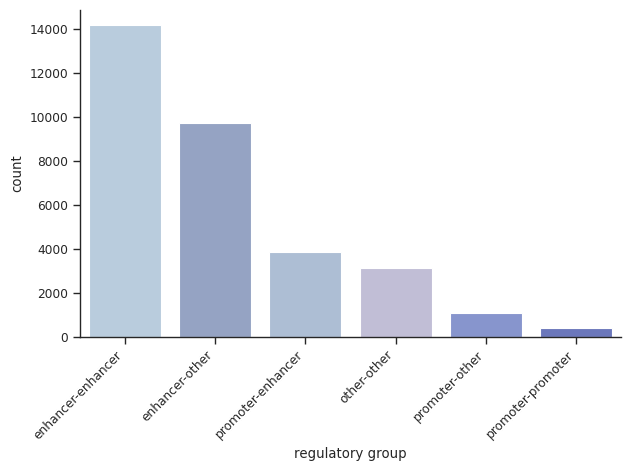

<Figure size 800x600 with 0 Axes>

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    style="ticks",
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')

custom_palette = [
    "#b3cde3",  # pastel blue (like Peakachu)
    "#8da0cb",  # mid blue (like Mustache)
    "#a6bddb",  # muted blue
    "#bebada",  # blue-lavender
    "#7b8ed9",  # strong blue
    "#5e6ec8",  # deep blue-purple (like Cooltools)
]
sns.set_palette(custom_palette)

cre_counts = loops["cre_categorization"].value_counts().reset_index()
cre_counts.columns = ["cre_categorization", "count"]

ax = sns.barplot(
    data=cre_counts,   # DataFrame as source
    x="cre_categorization",
    y="count",
    palette=custom_palette
)

ax.set_ylabel("count")
ax.set_xlabel("regulatory group")
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.figure(figsize=(8, 6))

In [19]:
loops.to_csv("ml_v8_loops.csv")